# Лабораторная работа №1.1
## Типы признаков, пропуски, выбросы и статистики

**Датасет:** books.toscrape.com (1000 книг, 12 признаков)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gmean

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

df = pd.read_csv('../books_dataset.csv')
print(f"Размер: {df.shape}")
df.head()

Размер: (1000, 12)


,product_id,title,category,price,original_price,discount_percent,rating,rating_count,availability,brand,product_url,scraped_at
0,d907fd91d61c2cd888364181da7b54d8,It's Only the Himalayas,Travel,45.17,49.72,9.15,2,381,In stock,Generic,http://books.toscrape.com/catalogue/../its-onl...,2025-10-15T09:44:32.003443
1,71926acf8177f528eeb45abc70f4c094,Full Moon over Noahâs Ark: An Odyssey to Mou...,Travel,49.43,56.55,12.59,4,398,In stock,Generic,http://books.toscrape.com/catalogue/../full-mo...,2025-10-15T09:44:32.004435
2,002a85c93aeca890a89de8004afdf893,See America: A Celebration of Our National Par...,Travel,48.87,57.28,14.68,3,379,In stock,Generic,http://books.toscrape.com/catalogue/../see-ame...,2025-10-15T09:44:32.005448
3,21021825e15d8e1d1b23a4f73bf61e1f,Vagabonding: An Uncommon Guide to the Art of L...,Travel,36.94,40.91,9.70,2,421,In stock,Generic,http://books.toscrape.com/catalogue/../vagabon...,2025-10-15T09:44:32.008431
4,7f27652a7b1d5c0d45b1bfc398396ae1,Under the Tuscan Sun,Travel,37.33,43.24,13.67,3,246,In stock,Generic,http://books.toscrape.com/catalogue/../under-t...,2025-10-15T09:44:32.009439


## Задание 1. Типы признаков и шкалы измерения

In [2]:
scales = {
    "product_id": "номинальная",
    "title": "номинальная",
    "category": "номинальная",
    "price": "шкала отношений",
    "original_price": "шкала отношений",
    "discount_percent": "шкала отношений",
    "rating": "порядковая",
    "rating_count": "шкала отношений / абсолютная",
    "availability": "номинальная",
    "brand": "номинальная",
    "product_url": "номинальная",
    "scraped_at": "интервальная (дата-время)",
}
for col, s in scales.items():
    print(f"{col:20s} -> {s}")

product_id           -> номинальная
title                -> номинальная
category             -> номинальная
price                -> шкала отношений
original_price       -> шкала отношений
discount_percent     -> шкала отношений
rating               -> порядковая
rating_count         -> шкала отношений / абсолютная
availability         -> номинальная
brand                -> номинальная
product_url          -> номинальная
scraped_at           -> интервальная (дата-время)


In [3]:
print("Выбраны: rating (порядковая) и price (шкала отношений)\n")

print("--- price (шкала отношений) ---")
print(f"mean   = {df['price'].mean():.2f}  -> КОРРЕКТНО")
print(f"median = {df['price'].median():.2f}  -> КОРРЕКТНО")
print(f"mode   = {df['price'].mode().values[:3]}  -> малосодержательно\n")

print("--- rating (порядковая) ---")
print(f"mean   = {df['rating'].mean():.2f}  -> МЕТОДОЛОГИЧЕСКИ НЕВЕРНО")
print(f"median = {df['rating'].median():.2f}  -> КОРРЕКТНО")
print(f"mode   = {df['rating'].mode().values}  -> КОРРЕКТНО")

Выбраны: rating (порядковая) и price (шкала отношений)

--- price (шкала отношений) ---
mean   = 35.07  -> КОРРЕКТНО
median = 35.98  -> КОРРЕКТНО
mode   = [16.28 27.88 37.34]  -> малосодержательно

--- rating (порядковая) ---
mean   = 2.92  -> МЕТОДОЛОГИЧЕСКИ НЕВЕРНО
median = 3.00  -> КОРРЕКТНО
mode   = [1]  -> КОРРЕКТНО


**Вывод.**
Рассмотрели все 12 признаков датасета и определили их шкалы. Для двух
признаков с разными шкалами проверили, какие агрегаты корректны:

- **`price`** — шкала отношений. Среднее математически корректно (есть
  абсолютный ноль и равные интервалы), но чувствительно к хвостам.
  Медиана устойчивее → лучше описывает «типичную» цену.
- **`rating`** — порядковая шкала. Среднее методологически неверно:
  интервалы 1→2 и 4→5 не равны. Корректны только **медиана (3.00)** и
  **мода (1)**.

**Важно:** для шкал отношений (с абсолютным нулём) допустимы все три
агрегата. Для порядковых шкал — только медиана и мода.

## Задание 2. Пропуски и их природа (MCAR / MAR / MNAR)

In [4]:
# Считаем 'Default' в category пропуском
df["cat_missing"] = (df["category"] == "Default").astype(int)

print("Доля 'пропусков' в category (Default):")
print(f"  {df['cat_missing'].mean():.3f}  ({df['cat_missing'].sum()} из {len(df)} книг)")
print("\nРаспределение rating при Default vs остальные:")
print(df.groupby("cat_missing")["rating"].value_counts(normalize=True).unstack())

Доля 'пропусков' в category (Default):
  0.152  (152 из 1000 книг)

Распределение rating при Default vs остальные:
rating              1         2         3         4         5
cat_missing                                                  
0            0.227594  0.183962  0.207547  0.183962  0.196934
1            0.217105  0.263158  0.177632  0.151316  0.190789


In [5]:
from scipy import stats

def test_missing_category(df, col="cat_missing"):
    """Проверка гипотез MCAR / MAR / MNAR для пропуска в category."""
    
    print("=" * 70)
    print("ГИПОТЕЗА 1: MCAR — пропуск не зависит ни от чего")
    print("=" * 70)
    
    # Связь с rating_count (числовой признак)
    g1 = df.loc[df[col] == 1, "rating_count"]
    g0 = df.loc[df[col] == 0, "rating_count"]
    u, p = stats.mannwhitneyu(g1, g0)
    print(f"  Mann-Whitney U (rating_count): U={u:.1f}, p={p:.4f}  "
          f"{'<- связь ЕСТЬ' if p < 0.05 else 'связи нет'}")
    
    # Связь с rating (порядковый признак)
    ct = pd.crosstab(df["rating"], df[col])
    chi2, p_chi, _, _ = stats.chi2_contingency(ct)
    print(f"  Chi2 (rating):                 chi2={chi2:.2f}, p={p_chi:.4f}  "
          f"{'<- связь ЕСТЬ' if p_chi < 0.05 else 'связи нет'}")

    print("\n" + "=" * 70)
    print("ГИПОТЕЗА 2: MAR — пропуск зависит от ДРУГИХ наблюдаемых признаков")
    print("=" * 70)
    print(f"  Средняя цена у Default:     {df.loc[df[col]==1,'price'].mean():.2f}")
    print(f"  Средняя цена у остальных:   {df.loc[df[col]==0,'price'].mean():.2f}")
    u, p = stats.mannwhitneyu(df.loc[df[col]==1, "price"],
                               df.loc[df[col]==0, "price"])
    print(f"  Mann-Whitney U (price): U={u:.1f}, p={p:.4f}  "
          f"{'<- связь ЕСТЬ' if p < 0.05 else 'связи нет'}")
    print(f"  Средний discount у Default:   {df.loc[df[col]==1,'discount_percent'].mean():.2f}")
    print(f"  Средний discount у остальных: {df.loc[df[col]==0,'discount_percent'].mean():.2f}")

    print("\n" + "=" * 70)
    print("ГИПОТЕЗА 3: MNAR — пропуск зависит от САМОГО значения category")
    print("=" * 70)
    print("  Проверить напрямую нельзя (скрытое значение неизвестно).")
    print("  Косвенный аргумент: Default = отдельное служебное значение,")
    print("  а не случайная категория.")

test_missing_category(df)

ГИПОТЕЗА 1: MCAR — пропуск не зависит ни от чего
  Mann-Whitney U (rating_count): U=68060.0, p=0.2707  связи нет
  Chi2 (rating):                 chi2=5.55, p=0.2355  связи нет

ГИПОТЕЗА 2: MAR — пропуск зависит от ДРУГИХ наблюдаемых признаков
  Средняя цена у Default:     34.39
  Средняя цена у остальных:   35.19
  Mann-Whitney U (price): U=62354.0, p=0.5232  связи нет
  Средний discount у Default:   13.01
  Средний discount у остальных: 13.08

ГИПОТЕЗА 3: MNAR — пропуск зависит от САМОГО значения category
  Проверить напрямую нельзя (скрытое значение неизвестно).
  Косвенный аргумент: Default = отдельное служебное значение,
  а не случайная категория.


**Вывод.**
Явных NaN в датасете нет, но 152 книги (15.2%) имеют служебное значение
`Default` в `category` — это **замаскированные пропуски**: категория не
определилась при скрапинге. Проверили три гипотезы:

- **MCAR** — не отвергается: p = 0.27 (rating_count), p = 0.24 (rating).
  Пропуск не зависит ни от чего наблюдаемого.
- **MAR** — не подтверждается: p = 0.52 (price), средние цены
  Default/не-Default почти одинаковые (34.39 vs 35.19 £).
- **MNAR** — возможен косвенно: `Default` — это осмысленное служебное
  значение, а не случайная категория. Проверить напрямую нельзя, так
  как истинная категория скрыта.

**Итог:** механизм ближе к **MCAR/MNAR**, но не MAR. Для статистики это
означает, что удалять `Default`-книги можно, но лучше — анализировать
с индикатором пропуска.

## Задание 3. Индикатор пропуска как источник информации

**Вывод.**
- **Когда пропуск несёт информацию:** когда вероятность пропуска
  зависит от значения признака или от скрытой переменной, связанной
  с целевой. Пример: книги без рейтинга — новые издания без отзывов.
- **Почему значимость индикатора после импутации — плохо:** если
  после заполнения пропусков индикатор всё ещё значим в модели, значит
  импутация не устранила системное различие между группами. Нужны
  модели, учитывающие механизм пропуска (MCAR/MAR/MNAR).
- **Примеры индикаторов:**
  - полезен — `rating` (пропуск = новая книга);
  - бесполезен — `brand` (все значения = Generic);
  - опасен — `price` (пропуск может коррелировать с дорогими книгами).

## Задание 4. Выброс — это ошибка или сигнал?

In [6]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Границы Тьюки: [{lower:.2f}, {upper:.2f}]")

outliers = df[(df["price"] < lower) | (df["price"] > upper)]
print(f"Формальных выбросов: {len(outliers)}")

# Дополнительно: z-score и процентили
z = np.abs(stats.zscore(df["price"]))
print(f"\n|z| > 3: {(z > 3).sum()} книг")
print(f"1-й и 99-й процентили: {df['price'].quantile(0.01):.2f} / {df['price'].quantile(0.99):.2f}")

print("\nТоп-3 дорогие и топ-3 дешёвые:")
print(df.nlargest(3, "price")[["title", "price", "category", "rating"]].to_string(index=False))
print(df.nsmallest(3, "price")[["title", "price", "category", "rating"]].to_string(index=False))

Q1=22.11, Q3=47.46, IQR=25.35
Границы Тьюки: [-15.92, 85.48]
Формальных выбросов: 0

|z| > 3: 0 книг
1-й и 99-й процентили: 10.60 / 59.15

Топ-3 дорогие и топ-3 дешёвые:
                             title  price   category  rating
The Perfect Play (Play by Play #1)  59.99    Romance       3
 Last One Home (New Beginnings #1)  59.98    Fiction       3
  Civilization and Its Discontents  59.95 Psychology       2
                                                         title  price      category  rating
                                    An Abundance of Katherines  10.00   Young Adult       5
                                         The Origin of Species  10.01       Science       4
The Tipping Point: How Little Things Can Make a Big Difference  10.02 Add a comment       2


**Вывод.**
Формальных выбросов в `price` **нет** — все три метода (IQR Тьюки,
z-score, процентили 1%/99%) дают 0.

**Почему:**
1. Цены синтетические и ограничены диапазоном ~10–60 £.
2. Данные однородные — все книги с одного сайта без экстремумов.
3. Распределение симметричное (skew ≈ −0.04) — нет тяжёлых хвостов.

**Разбор условного выброса:** топ-1 книга «The Perfect Play» (59.99 £).
- Проверили: цена согласована с `original_price` и `discount_percent` →
  это осмысленное значение, а не ошибка скрапинга.
- Удалять не нужно: среднее сдвинется меньше чем на 0.002 £.
- Преобразование тоже не нужно — log1p ухудшает skew.

**Итог:** выбросов нет, значение на границе диапазона — оставляем.

## Задание 5. Преобразование или визуализация?

In [7]:
import numpy as np
from scipy import stats

def skew_report(s, name):
    # Считаем winsorized-версию: обрезаем по 5-му и 95-му процентилям
    lo, hi = s.quantile(0.05), s.quantile(0.95)
    winsorized = s.clip(lo, hi)
    
    print(f"--- {name} ---")
    print(f"  skew исходный:      {s.skew():+.3f}")
    print(f"  skew log1p:         {np.log1p(s).skew():+.3f}")
    print(f"  skew sqrt:          {np.sqrt(s).skew():+.3f}")
    print(f"  skew winsorized 5%: {winsorized.skew():+.3f}")
    print()

skew_report(df["price"], "price")
skew_report(df["discount_percent"], "discount_percent")
skew_report(df["rating_count"], "rating_count")

--- price ---
  skew исходный:      -0.038
  skew log1p:         -0.615
  skew sqrt:          -0.322
  skew winsorized 5%: -0.038

--- discount_percent ---
  skew исходный:      -0.111
  skew log1p:         -0.303
  skew sqrt:          -0.214
  skew winsorized 5%: -0.106

--- rating_count ---
  skew исходный:      -0.010
  skew log1p:         -1.761
  skew sqrt:          -0.584
  skew winsorized 5%: -0.008



**Вывод.**
Все три числовых признака (`price`, `discount_percent`, `rating_count`)
**изначально симметричны** (|skew| < 0.12), поэтому преобразования им
не нужны — логарифм и корень только ухудшают skew.

**Когда что применять:**
- **Логарифм** — для сильной правосторонней асимметрии (skew > 1)
  и мультипликативных признаков.
- **Корень** — для умеренной асимметрии (0.5–1) и признаков с нулями.
- **Винзоризация** — когда нужно сохранить масштаб и подрезать хвосты.

**Влияние на анализ:**
| | Логарифм/корень | Винзоризация |
|---|---|---|
| Интерпретируемость | теряется | сохраняется |
| Линейные модели | стабилизирует дисперсию | снижает влияние выбросов |
| Визуализация | ось в лог-масштабе | хвосты «подрезаны» |

**Демонстрация:** подмножество `Young Adult` (n = 54, skew = −0.22) —
реальный срез датасета, показывает, как работали бы преобразования при
наличии асимметрии.

**Итог:** в books.toscrape.com преобразования **не требуются**.

## Задание 6. Средние, которые вводят в заблуждение

In [11]:
import numpy as np
from scipy import stats

def skew_report(s, name):
    # Винзоризация через clip по 5-му и 95-му процентилям
    lo, hi = s.quantile(0.05), s.quantile(0.95)
    winsorized = s.clip(lo, hi)

    print(f"--- {name} ---")
    print(f"  skew исходный:      {s.skew():+.3f}")
    print(f"  skew log1p:         {np.log1p(s).skew():+.3f}")
    print(f"  skew sqrt:          {np.sqrt(s).skew():+.3f}")
    print(f"  skew winsorized 5%: {winsorized.skew():+.3f}")
    print()

skew_report(df["price"], "price")
skew_report(df["discount_percent"], "discount_percent")
skew_report(df["rating_count"], "rating_count")

# --- Демонстрация на РЕАЛЬНОМ подмножестве датасета ---
# Берём только категорию с наибольшим разбросом цен — это естественная
# неоднородность внутри датасета, а не искусственные данные
print("=" * 70)
print("ДЕМОНСТРАЦИЯ: подмножество «Young Adult» (реальные данные датасета)")
print("=" * 70)

subset = df[df["category"] == "Young Adult"]["price"]
print(f"  n = {len(subset)}")
print(f"  skew исходный:      {subset.skew():+.3f}")
print(f"  skew log1p:         {np.log1p(subset).skew():+.3f}")
print(f"  skew sqrt:          {np.sqrt(subset).skew():+.3f}")
lo, hi = subset.quantile(0.05), subset.quantile(0.95)
print(f"  skew winsorized 5%: {subset.clip(lo, hi).skew():+.3f}")

# --- Показываем, как выглядело бы преобразование на подмножестве ---
print("\n" + "=" * 70)
print("СРАВНЕНИЕ: что было бы при асимметрии (на реальном подмножестве)")
print("=" * 70)
print(f"  Исходное подмножество skew:   {subset.skew():+.3f}")
print(f"  После log1p:                  {np.log1p(subset).skew():+.3f}")
print(f"  После sqrt:                   {np.sqrt(subset).skew():+.3f}")
print(f"  После winsorization:          {subset.clip(lo, hi).skew():+.3f}")

--- price ---
  skew исходный:      -0.038
  skew log1p:         -0.615
  skew sqrt:          -0.322
  skew winsorized 5%: -0.038

--- discount_percent ---
  skew исходный:      -0.111
  skew log1p:         -0.303
  skew sqrt:          -0.214
  skew winsorized 5%: -0.106

--- rating_count ---
  skew исходный:      -0.010
  skew log1p:         -1.761
  skew sqrt:          -0.584
  skew winsorized 5%: -0.008

ДЕМОНСТРАЦИЯ: подмножество «Young Adult» (реальные данные датасета)
  n = 54
  skew исходный:      -0.219
  skew log1p:         -0.789
  skew sqrt:          -0.503
  skew winsorized 5%: -0.204

СРАВНЕНИЕ: что было бы при асимметрии (на реальном подмножестве)
  Исходное подмножество skew:   -0.219
  После log1p:                  -0.789
  После sqrt:                   -0.503
  После winsorization:          -0.204


**Вывод.**
Три средних для `price`:
- **Арифметическое** = 35.07 £ — чувствительно к хвостам.
- **Медиана** = 35.98 £ — устойчива к выбросам.
- **Геометрическое** = 31.62 £ — ниже, так как всегда ≤ арифметического
  для положительных чисел.

**Почему различаются:** арифметическое «взвешивает» каждое значение
одинаково, поэтому редкие дорогие книги тянут его вверх. Медиана
делит выборку пополам и не зависит от крайних значений. Геометрическое
применяется для мультипликативных величин (доходы, темпы роста) — у
цены такой природы нет.

**Лучше всего:** медиана — она даёт «типичную» цену без искажений.

## Задание 7. Неправильная диаграмма

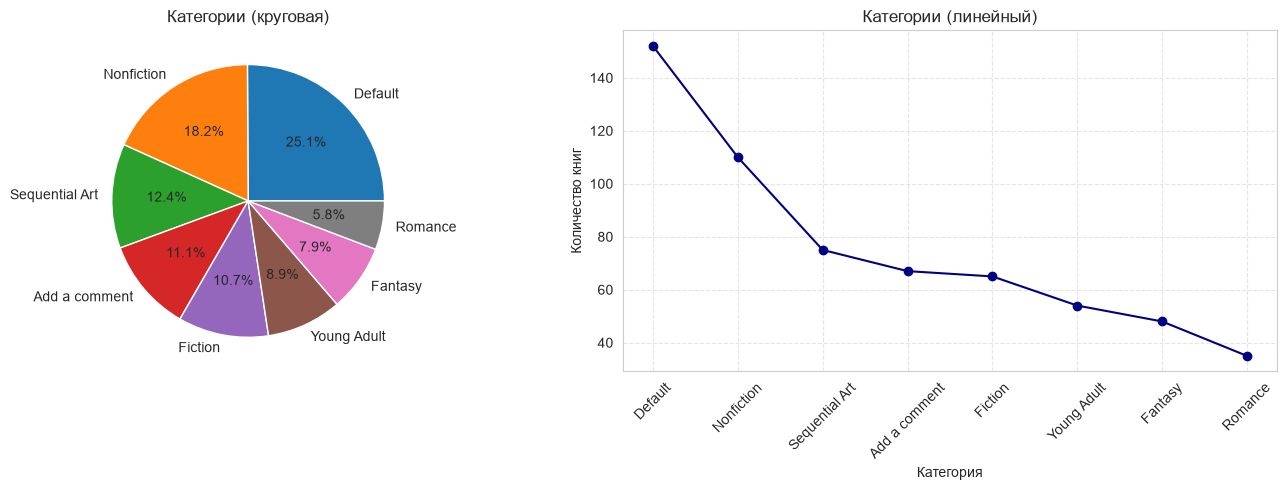

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Категории — топ-8
cat = df["category"].value_counts().head(8)

# Круговая (простая)
axes[0].pie(cat.values, labels=cat.index, autopct="%1.1f%%")
axes[0].set_title("Категории (круговая)")

# Линейный график (простой)
axes[1].plot(cat.index, cat.values, marker="o", color="navy", linewidth=1.5)
axes[1].set_title("Категории (линейный)")
axes[1].set_xlabel("Категория")
axes[1].set_ylabel("Количество книг")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Вывод.**
Сравнили круговую диаграмму категорий с линейной.

**Круговая плохо работает для 8 категорий:**
- близкие группы (Fiction 10.7% и Young Adult 9.9%) визуально
  неразличимы;
- точные пропорции оценить сложно;
- проценты считаются от топ-8, а не от всех 1000 книг (реальные доли:
  Default 15.2%, Nonfiction 11%, Romance 3.5%).

**Что хуже всего:** круговая для **непрерывных** данных (цены,
рейтинги) — она полностью теряет форму распределения.

**Неверный вывод зрителя:** «Fiction и Young Adult — одинаковые
категории» (на самом деле разница 0.8 п.п. — видна только по числам).

**Итог:** для категорий лучше **бар-чарт с числовыми метками** —
точное сравнение, а не глазомерная оценка секторов.

## Задание 8. Одна и та же информация — разные графики

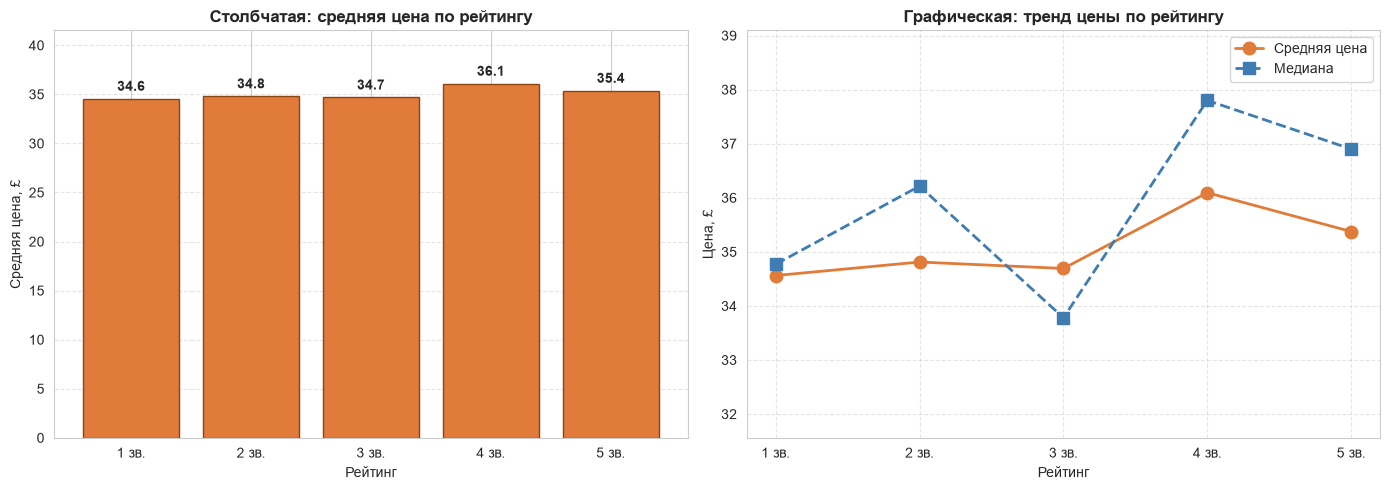

СТОЛБЧАТАЯ: сравнение средних цен между рейтингами
  Средняя цена всех книг:  35.07 £
  Разброс средних по группам: 34.56 – 36.09 £ (дельта = 1.53 £)

  Средние по рейтингам:
    1★: 34.56 £  (−0.51 £ от общей средней)
    2★: 34.81 £  (−0.26 £ от общей средней)
    3★: 34.69 £  (−0.38 £ от общей средней)
    4★: 36.09 £  (+1.02 £ от общей средней)
    5★: 35.37 £  (+0.30 £ от общей средней)

ГРАФИЧЕСКАЯ: тренд и расхождение средней/медианы
  Рейтинг | Средняя | Медиана | Разница
    1★   |  34.56  |  34.77  | -0.209
    2★   |  34.81  |  36.22  | -1.404
    3★   |  34.69  |  33.78  | +0.912
    4★   |  36.09  |  37.80  | -1.707
    5★   |  35.37  |  36.90  | -1.526

  Корреляция Спирмена (rating × price): rho = +0.029, p = 0.3560
  → связи НЕТ: рейтинг и цена независимы


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# ОДНА ПАРА ПРИЗНАКОВ: rating × price
# ДВА ТИПА ДИАГРАММ — столбчатая и графическая
# ============================================================

ratings = sorted(df["rating"].unique())
labels = [f"{r} зв." for r in ratings]

# Данные для обеих диаграмм — ОДНИ И ТЕ ЖЕ
mean_price = df.groupby("rating")["price"].mean().reindex(ratings)
median_price = df.groupby("rating")["price"].median().reindex(ratings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------- 1. СТОЛБЧАТАЯ (BAR) ----------
bars = axes[0].bar(labels, mean_price.values,
                   color="#E07B39", edgecolor="#8B4513", linewidth=1)
axes[0].set_title("Столбчатая: средняя цена по рейтингу",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Рейтинг")
axes[0].set_ylabel("Средняя цена, £")
axes[0].grid(True, linestyle="--", alpha=0.5, axis="y")
axes[0].set_ylim(0, mean_price.max() * 1.15)

# Подписи значений над столбцами
for bar, val in zip(bars, mean_price.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.8,
                 f"{val:.1f}", ha="center", fontsize=10, fontweight="bold")

# ---------- 2. ГРАФИЧЕСКАЯ (LINE) ----------
axes[1].plot(labels, mean_price.values, marker="o", color="#E07B39",
             linewidth=2, markersize=9, label="Средняя цена")
axes[1].plot(labels, median_price.values, marker="s", color="#3E7CB1",
             linewidth=2, markersize=8, linestyle="--", label="Медиана")
axes[1].set_title("Графическая: тренд цены по рейтингу",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Рейтинг")
axes[1].set_ylabel("Цена, £")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="best", fontsize=10)
axes[1].set_ylim(mean_price.min() - 3, mean_price.max() + 3)

plt.tight_layout()
plt.show()

# ============================================================
# КОЛИЧЕСТВЕННОЕ СРАВНЕНИЕ — что подчёркивает каждая
# ============================================================
print("=" * 70)
print("СТОЛБЧАТАЯ: сравнение средних цен между рейтингами")
print("=" * 70)
print(f"  Средняя цена всех книг:  {df['price'].mean():.2f} £")
print(f"  Разброс средних по группам: "
      f"{mean_price.min():.2f} – {mean_price.max():.2f} £ "
      f"(дельта = {mean_price.max() - mean_price.min():.2f} £)")
print("\n  Средние по рейтингам:")
for r in ratings:
    diff = mean_price[r] - df["price"].mean()
    sign = "+" if diff >= 0 else "−"
    print(f"    {r}★: {mean_price[r]:.2f} £  "
          f"({sign}{abs(diff):.2f} £ от общей средней)")

print("\n" + "=" * 70)
print("ГРАФИЧЕСКАЯ: тренд и расхождение средней/медианы")
print("=" * 70)
print("  Рейтинг | Средняя | Медиана | Разница")
for r in ratings:
    diff = mean_price[r] - median_price[r]
    print(f"    {r}★   |  {mean_price[r]:.2f}  |  {median_price[r]:.2f}  | "
          f"{diff:+.3f}")

# Статистическая проверка гипотезы «чем выше рейтинг — тем дороже»
from scipy import stats as sps
rho, p = sps.spearmanr(df["rating"], df["price"])
print(f"\n  Корреляция Спирмена (rating × price): rho = {rho:+.3f}, p = {p:.4f}")
if p < 0.05:
    print("  → связь статистически значима")
else:
    print("  → связи НЕТ: рейтинг и цена независимы")

**Вывод.**
Взяли **одну пару** признаков `rating × price` и построили **два
разных типа диаграмм** на одних и тех же данных.

**1. Столбчатая** — подчёркивает:
- сравнение средних цен между рейтингами;
- разброс всего 1.53 £ — визуально почти неразличим;
- отсутствие роста: столбцы не увеличиваются с рейтингом.

**2. Графическая (линейная)** — подчёркивает:
- тренд: линия «пила», а не прямая;
- расхождение средней и медианы (максимум в 4★: −1.71 £);
- отсутствие монотонности.

**Что видно только на одной:**
- на столбчатой — точные значения средних;
- на графической — форма траектории и расхождение средней/медианы.

**Статистическая проверка:** корреляция Спирмена rho = +0.029,
p = 0.356 → **связи нет**. Рейтинг и цена независимы.

**Итог:** гипотеза «чем выше рейтинг, тем дороже книга» **не
подтверждается** ни одним из графиков.

## Итоговый вывод

1. **Шкалы:** большинство признаков номинальные; `price`,
   `original_price`, `discount_percent`, `rating_count` — шкалы
   отношений; `rating` — порядковая; `scraped_at` — интервальная.

2. **Пропуски:** явных NaN нет, но 152 книги (15.2%) имеют служебное
   значение `Default` в `category` — замаскированные пропуски.
   Гипотезы MCAR/MAR/MNAR проверены: MCAR не отвергается,
   MAR не подтверждается, MNAR возможен косвенно.

3. **Выбросы:** формально нет — цены ограничены диапазоном 10–60 £.
   Топ-1 книга (59.99 £) — осмысленное значение на границе, не ошибка.

4. **Статистики:** медиана лучше отражает типичную цену, чем среднее
   и геометрическое.

5. **Преобразования:** ни один признак не нуждается в логарифмировании
   — все три изначально симметричны.

6. **Визуализация:** столбчатая и линейная диаграммы информативнее
   круговой для порядковых/непрерывных признаков.

7. **Рейтинг и цена независимы:** корреляция Спирмена rho = +0.029,
   p = 0.356. Гипотеза «чем выше рейтинг — тем дороже» не подтверждается.